# Conditional Factor Model for Stock Return Prediction

This notebook implements the Conditional Factor Model architecture per CLAUDE.md:

$$\hat{r}_{i,t+H} = b_{i,t}^{\top} \lambda_t$$

## Architecture Overview

1. **Factor Premia Model** $\lambda_t = g(m_t)$: Multi-Scale Liquid SSM
   - Takes market state vector $m_t$ (sentiment, volatility, regime features)
   - Outputs time-varying prices of risk (same for all stocks at time $t$)
   
2. **Stock Exposure Model** $b_{i,t} = f(x_{i,t})$: 3-layer MLP
   - Takes stock-specific features $x_{i,t}$ (momentum, size, fundamentals)
   - Outputs latent factor exposures (stock-specific)
   
3. **Prediction**: Element-wise product $b_{i,t} \odot \lambda_t$ → scalar return

**Key Insight**: Sentiment and volatility shape the *prices of risk*, not stock rankings directly.

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import gc
from typing import List, Dict, Tuple, Optional, Any
from collections import OrderedDict, defaultdict
from dataclasses import dataclass

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Data Configuration

In [2]:
# ============= Data Paths =============
# Market state vector - LOCAL DISK
MARKET_DATA_PATH = "/Users/gabriel/Desktop/Sentiment Model/market_training_data_final/market_state_vector.parquet"

# Stock features - LOCAL DISK for fast I/O
STOCK_DATA_DIR = "/Users/gabriel/Desktop/Sentiment Model/stock_training_data_final"

# Get list of all batch files
STOCK_BATCH_FILES = sorted([f for f in os.listdir(STOCK_DATA_DIR) if f.endswith('.parquet')])
N_STOCK_BATCHES = len(STOCK_BATCH_FILES)

print(f"Market data path: {MARKET_DATA_PATH}")
print(f"Stock data directory: {STOCK_DATA_DIR}")
print(f"Number of stock batch files: {N_STOCK_BATCHES}")

Market data path: /Users/gabriel/Desktop/Sentiment Model/market_training_data_final/market_state_vector.parquet
Stock data directory: /Users/gabriel/Desktop/Sentiment Model/stock_training_data_final
Number of stock batch files: 59


In [3]:
# ============= Model Configuration =============
# Target column (defined here, will be dropped from features)
TARGET_COL = 'target_ret_1d'

# Multi-scale configuration
TARGET_PATCHES = 30
PATCH_SIZES = [None, 10, 63]

# Calculate required sequence length
max_patch_size = max([p for p in PATCH_SIZES if p is not None])
SEQ_LEN = TARGET_PATCHES + max_patch_size - 1

# Model hyperparameters
N_FACTORS = 16
D_MODEL = 32
N_LIQUID_LAYERS = 1
D_STATE = 16

# Training configuration - Phase A (main training)
LEARNING_RATE = 0.001
BATCH_SIZE = 64              # Tickers per batch
STEPS_PER_EPOCH = 150        # Random samples per epoch
VAL_STEPS = 50               # Validation samples per evaluation
EPOCHS_PER_WINDOW = 100       # Epochs per window
PATIENCE = 20                # Early stopping patience
DECAY = 0.75
LR_DECAY_STEPS = 10           # Reduce LR if no improvement every N steps,
SHOW_RATE = 1

# Phase B configuration (fine-tuning on validation data)
PHASE_B_EPOCHS = 10           # Fine-tuning epochs on validation data
PHASE_B_LR = 0.0005          # Lower learning rate for fine-tuning
PHASE_B_STEPS_PER_EPOCH = 200 # Steps per epoch during fine-tuning

# Walk-forward validation
TRAIN_YEARS = 1.0            # 1 year training window
VAL_YEARS = 2 / 52           # 2 weeks validation/test windows

# Parquet rotation optimization
# Instead of reading from all 59 parquets each step (slow),
# we select N_ACTIVE_PARQUETS and use them for STEPS_PER_ROTATION steps.
# This leverages OS file caching for ~5-10x speedup.
N_ACTIVE_PARQUETS = 4        # Number of parquet files to use at a time
STEPS_PER_ROTATION = 10      # How many steps before rotating to new parquets

# Metadata cache path
METADATA_CACHE_PATH = 'metadata_index.pkl'

print(f"Target column: {TARGET_COL}")
print(f"Target patches: {TARGET_PATCHES}")
print(f"Patch sizes: {PATCH_SIZES}")
print(f"Sequence length: {SEQ_LEN} days")
print(f"Number of latent factors: {N_FACTORS}")
print(f"Batch size (tickers per batch): {BATCH_SIZE}")
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"\n2-Phase Learning:")
print(f"  Phase A: {TRAIN_YEARS} years train, {VAL_YEARS:.4f} years val (~{int(365.25 * VAL_YEARS)} days)")
print(f"  Phase B: {PHASE_B_EPOCHS} epochs fine-tuning at LR={PHASE_B_LR}")
print(f"  Test: Next {int(365.25 * VAL_YEARS)} days (true out-of-sample)")
print(f"\nParquet Optimization:")
print(f"  Active parquets: {N_ACTIVE_PARQUETS} (out of 59)")
print(f"  Steps per rotation: {STEPS_PER_ROTATION}")

Target column: target_ret_1d
Target patches: 30
Patch sizes: [None, 10, 63]
Sequence length: 92 days
Number of latent factors: 16
Batch size (tickers per batch): 64
Steps per epoch: 150

2-Phase Learning:
  Phase A: 1.0 years train, 0.0385 years val (~14 days)
  Phase B: 10 epochs fine-tuning at LR=0.0005
  Test: Next 14 days (true out-of-sample)

Parquet Optimization:
  Active parquets: 4 (out of 59)
  Steps per rotation: 10


## 3. Model Architecture Components

In [4]:
class IndicatorMixing(nn.Module):
    """
    Per-timestep MLP that mixes features across indicators.
    Input: (B, T, F_raw)
    Output: (B, T, D)
    """
    def __init__(self, f_raw, d_model, hidden_dim=None):
        super().__init__()
        if hidden_dim is None:
            hidden_dim = d_model 

        self.mlp = nn.Sequential(
            nn.Linear(f_raw, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, d_model),
            nn.LayerNorm(d_model)
        )

    def forward(self, x):
        return self.mlp(x)

In [5]:
class OverlappingPatchEmbedding(nn.Module):
    """
    Overlapping patch embedding with stride=1 (rolling window).
    """
    def __init__(self, d_model, patch_size, target_patches):
        super().__init__()
        self.patch_size = patch_size
        self.d_model = d_model
        self.target_patches = target_patches
        self.required_input_length = target_patches + patch_size - 1

        self.conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=patch_size,
            stride=1,
            padding=0,
            groups=d_model
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, D = x.shape
        required_T = self.required_input_length

        if T < required_T:
            padding = required_T - T
            x = F.pad(x, (0, 0, padding, 0))
        elif T > required_T:
            x = x[:, -required_T:, :]

        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        x = self.norm(x)

        return x

In [6]:
class CustomLiquid(nn.Module):
    """
    Custom Liquid SSM implementation following Equation 9 from the paper.
    """
    def __init__(self, d_model: int, d_state: int = 16, d_conv: int = 4, expand: int = 2, bias: bool = False, **kwargs):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        self.A_bar = nn.Parameter(torch.randn(d_state, d_state))
        self.B_bar = nn.Parameter(torch.randn(d_state))
        self.C = nn.Parameter(torch.randn(d_model, d_state))
        self.W_u = nn.Linear(d_model, d_state, bias=False)

        nn.init.xavier_uniform_(self.A_bar)
        nn.init.xavier_uniform_(self.B_bar.unsqueeze(0))
        nn.init.xavier_uniform_(self.C)
        nn.init.xavier_uniform_(self.W_u.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.selective_ssm(x)

    def selective_ssm(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        u = self.W_u(x)
        h = torch.zeros(B, self.d_state, 1, device=x.device, dtype=x.dtype)

        A_bar = self.A_bar.unsqueeze(0).expand(B, -1, -1)
        B_bar = self.B_bar.unsqueeze(0).expand(B, -1)
        C = self.C.unsqueeze(0).expand(B, -1, -1)

        outputs = []
        for t in range(L):
            u_t = u[:, t, :]
            B_u = B_bar * u_t
            B_u_diag = torch.diag_embed(B_u)
            A_modified = A_bar + B_u_diag
            h = torch.bmm(A_modified, h) + B_u.unsqueeze(-1)
            y_t = torch.bmm(C, h).squeeze(-1)
            outputs.append(y_t)

        return torch.stack(outputs, dim=1)


class CustomLiquidEncoder(nn.Module):
    def __init__(self, d_model: int, n_layers: int = 2, d_state: int = 16, d_conv: int = 4, expand: int = 2):
        super().__init__()
        self.layers = nn.ModuleList([
            CustomLiquid(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x) + x
        return self.norm(x)


class LSTMEncoder(nn.Module):
    """LSTM encoder with same interface as CustomLiquidEncoder."""
    def __init__(self, d_model: int, n_layers: int = 2, d_state: int = 16, d_conv: int = 4, expand: int = 2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        
        # Input projection: d_model -> d_state
        self.proj_in = nn.Linear(d_model, d_state)
        
        # LSTM operates in d_state space
        self.lstm = nn.LSTM(
            input_size=d_state,
            hidden_size=d_state,
            num_layers=n_layers,
            batch_first=True,
            dropout=0.1 if n_layers > 1 else 0.0
        )
        
        # Output projection: d_state -> d_model
        self.proj_out = nn.Linear(d_state, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj_in(x)       # (B, T, d_model) -> (B, T, d_state)
        out, _ = self.lstm(x)     # (B, T, d_state)
        out = self.proj_out(out)  # (B, T, d_state) -> (B, T, d_model)
        return self.norm(out)

In [7]:
class FactorPremiaHead(nn.Module):
    """Factor premia output head. Outputs (B, T, n_factors)."""
    def __init__(self, input_dim, n_factors):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(input_dim // 2, n_factors)
        )

    def forward(self, x):
        return self.head(x)

In [8]:
class MultiScaleLiquid(nn.Module):
    """Multi-Scale Liquid architecture for factor premia λ_t = g(m_t)."""
    def __init__(self, f_raw, n_factors, d_model=128, target_patches=30, n_liquid_layers=2,
                 d_state=16, d_conv=4, expand=2, patch_sizes=[None, 7, 30], 
                 encoder_type='liquid'):
        super().__init__()
        self.d_model = d_model
        self.target_patches = target_patches
        self.patch_sizes = patch_sizes
        self.num_scales = len(patch_sizes)

        self.indicator_mixing = IndicatorMixing(f_raw, d_model)
        self.patch_embeddings = nn.ModuleList([
            OverlappingPatchEmbedding(d_model, p, target_patches) if p is not None else None
            for p in patch_sizes
        ])
        
        # Select encoder type: 'liquid' (default) or 'lstm'
        EncoderClass = LSTMEncoder if encoder_type == 'lstm' else CustomLiquidEncoder
        self.liquid_encoders = nn.ModuleList([
            EncoderClass(d_model=d_model, n_layers=n_liquid_layers, d_state=d_state)
            for _ in patch_sizes
        ])
        self.premia_head = FactorPremiaHead(self.num_scales * d_model, n_factors)

    def forward(self, x):
        h0 = self.indicator_mixing(x)
        scale_outputs = []
        for patch_embed, liquid_encoder in zip(self.patch_embeddings, self.liquid_encoders):
            if patch_embed is None:
                B, T, D = h0.shape
                if T > self.target_patches:
                    z = h0[:, -self.target_patches:, :]
                elif T < self.target_patches:
                    z = F.pad(h0, (0, 0, self.target_patches - T, 0))
                else:
                    z = h0
            else:
                z = patch_embed(h0)
            scale_outputs.append(liquid_encoder(z))
        return self.premia_head(torch.cat(scale_outputs, dim=-1))

In [9]:
class StockExposureModel(nn.Module):
    """Stock Exposure Model: b_{i,t} = f(x_{i,t}). 3-layer MLP."""
    def __init__(self, f_stock, n_factors, hidden_dim=None):
        super().__init__()
        if hidden_dim is None:
            hidden_dim = 2 * n_factors
        self.mlp = nn.Sequential(
            nn.Linear(f_stock, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_factors)
        )
    
    def forward(self, x):
        return self.mlp(x)

In [10]:
class LiquidPremia(nn.Module):
    """
    Conditional Factor Model: r̂_{i,t+H} = b_{i,t}^T λ_t + α_t
    
    - λ_t = g(m_t): Factor premia from market state (MultiScaleLiquid)
    - b_{i,t} = f(x_{i,t}): Stock exposures from stock features (3-layer MLP)
    - α_t = h(m_t): Time-varying intercept from market state (optional)
    """
    def __init__(self, f_market, n_factors, d_model=32, target_patches=30, n_liquid_layers=1,
                 d_state=16, d_conv=4, expand=2, patch_sizes=[None, 14],
                 f_stock=None, stock_hidden_dim=None, encoder_type='liquid',
                 use_alpha=True):
        super().__init__()
        self.n_factors = n_factors
        self.target_patches = target_patches
        self.use_alpha = use_alpha
        
        self.factor_premia_model = MultiScaleLiquid(
            f_raw=f_market, n_factors=n_factors, d_model=d_model,
            target_patches=target_patches, n_liquid_layers=n_liquid_layers,
            d_state=d_state, d_conv=d_conv, expand=expand, patch_sizes=patch_sizes,
            encoder_type=encoder_type
        )
        
        self.stock_exposure_model = StockExposureModel(
            f_stock=f_stock, n_factors=n_factors, hidden_dim=stock_hidden_dim
        ) if f_stock is not None else None
        
        # Alpha head: time-varying intercept from factor premia (reuses λ_t)
        if use_alpha:
            self.alpha_head = nn.Linear(n_factors, 1)
            nn.init.xavier_uniform_(self.alpha_head.weight, gain=0.1)
            nn.init.zeros_(self.alpha_head.bias)
    
    def forward(self, market_features, stock_features=None):
        lambda_t = self.factor_premia_model(market_features)
        
        if self.stock_exposure_model is not None and stock_features is not None:
            b_it = self.stock_exposure_model(stock_features).unsqueeze(1)
            y_pred = (lambda_t * b_it).sum(dim=-1, keepdim=True)
        else:
            y_pred = lambda_t.sum(dim=-1, keepdim=True)
        
        # Add time-varying intercept α_t (same for all stocks at time t)
        if self.use_alpha:
            alpha_t = self.alpha_head(lambda_t)  # (B, T, 1)
            y_pred = y_pred + alpha_t
        
        return y_pred

## 4. Data Loading

In [11]:
# Load market state vector (stays constant throughout training)
print(f"Loading market state vector...")
market_df = pd.read_parquet(MARKET_DATA_PATH)

# Ensure datetime index
if not isinstance(market_df.index, pd.DatetimeIndex):
    market_df.index = pd.to_datetime(market_df.index)

# Remove timezone if present for easier alignment
if market_df.index.tz is not None:
    market_df.index = market_df.index.tz_localize(None)

print(f"Market state vector shape: {market_df.shape}")
print(f"Date range: {market_df.index.min()} to {market_df.index.max()}")
print(f"Features: {len(market_df.columns)}")

Loading market state vector...
Market state vector shape: (3410, 223)
Date range: 2012-01-04 00:00:00 to 2025-12-03 00:00:00
Features: 223


In [12]:
def load_stock_batches(batch_indices):
    """
    Load and concatenate multiple stock batch files.
    
    Args:
        batch_indices: List of batch indices to load
    
    Returns:
        Concatenated DataFrame with all stocks from selected batches
    """
    dfs = []
    for idx in batch_indices:
        batch_file = STOCK_BATCH_FILES[idx]
        batch_path = os.path.join(STOCK_DATA_DIR, batch_file)
        df = pd.read_parquet(batch_path)
        dfs.append(df)
    
    stock_df = pd.concat(dfs, axis=0, ignore_index=True)
    
    # Convert date column to datetime index
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    if stock_df['date'].dt.tz is not None:
        stock_df['date'] = stock_df['date'].dt.tz_localize(None)
    
    return stock_df

In [13]:
# Test loading a batch to get feature dimensions
test_stock_df = load_stock_batches([0])
print(f"Test batch shape: {test_stock_df.shape}")
print(f"Columns: {test_stock_df.columns[:10].tolist()} ...")
print(f"Tickers in batch: {test_stock_df['ticker'].nunique()}")

# Get DYNAMIC feature columns (excluding date, ticker, and target columns)
target_cols = [c for c in test_stock_df.columns if c.startswith('target_')]
non_feature_cols = ['date', 'ticker'] + target_cols
dynamic_feature_cols = [c for c in test_stock_df.columns if c not in non_feature_cols]

print(f"\nTarget columns: {target_cols}")
print(f"Dynamic feature columns: {len(dynamic_feature_cols)}")

del test_stock_df
gc.collect()

# Load STATIC features (sector/industry/country embeddings, mcap)
# These are ticker-level features that don't change over time
STATIC_FEATURES_PATH = 'stock_market_features.csv'
static_features_df = pd.read_csv(STATIC_FEATURES_PATH)
static_features_df = static_features_df.set_index('ticker')
static_feature_cols = list(static_features_df.columns)

print(f"\nStatic features loaded: {len(static_feature_cols)} columns")
print(f"  Tickers with static features: {len(static_features_df)}")
print(f"  Columns: {static_feature_cols[:5]} ...")

# Combined feature columns (dynamic from parquet + static from CSV)
stock_feature_cols = dynamic_feature_cols + static_feature_cols
print(f"\nTotal stock feature columns: {len(stock_feature_cols)}")
print(f"  Dynamic: {len(dynamic_feature_cols)}")
print(f"  Static: {len(static_feature_cols)}")

Test batch shape: (93144, 175)
Columns: ['date', 'ticker', 'dist_to_ema_3_pct', 'dist_to_ema_5_pct', 'dist_to_ema_10_pct', 'dist_to_ema_21_pct', 'dist_to_ema_63_pct', 'dist_to_ema_126_pct', 'ema3_above_ema5', 'ema3_above_ema10'] ...
Tickers in batch: 50

Target columns: ['target_ret_1d', 'target_ret_3d', 'target_ret_5d', 'target_ret_10d', 'target_ret_21d']
Dynamic feature columns: 168

Static features loaded: 34 columns
  Tickers with static features: 3098
  Columns: ['sector_emb_0', 'sector_emb_1', 'sector_emb_2', 'sector_emb_3', 'sector_emb_4'] ...

Total stock feature columns: 202
  Dynamic: 168
  Static: 34


## 4b. Fixed-Window Training Infrastructure

The following classes implement memory-efficient fixed-window training:
1. **MetadataIndex**: Precomputed ticker→parquet mapping and date availability
2. **DateWindowSampler**: Samples training date windows and available tickers  
3. **ParquetCacheManager**: LRU cache for parquet files (max 3 in memory)
4. **ConditionalFactorDatasetV2**: Fixed-window dataset with masking for missing data

In [14]:
# ============= 1. MetadataIndex: Precomputed ticker→parquet mapping =============
from dataclasses import dataclass
from typing import Dict, Set, List, Tuple, Optional
from collections import defaultdict, OrderedDict
import pickle

@dataclass
class TickerMetadata:
    """Metadata for a single ticker."""
    ticker: str
    batch_idx: int           # Which batch file (0-58)
    min_date: pd.Timestamp   # First available date
    max_date: pd.Timestamp   # Last available date
    n_rows: int              # Total rows
    date_set: frozenset      # Set of available dates (for gap detection)


class MetadataIndex:
    """
    Precomputed index for efficient data loading.
    
    Enables O(1) lookup of:
    - Which parquet file contains which ticker
    - What date range each ticker has data for
    - Which dates have data for each ticker (for gap detection)
    """
    
    def __init__(self, stock_data_dir: str, batch_files: List[str], cache_path: str = None):
        """
        Build or load the metadata index.
        
        Args:
            stock_data_dir: Path to stock_training_data_final/
            batch_files: List of batch file names
            cache_path: Optional path to save/load pickled index
        """
        self.stock_data_dir = stock_data_dir
        self.batch_files = batch_files
        self.ticker_to_meta: Dict[str, TickerMetadata] = {}
        self.batch_to_tickers: Dict[int, Set[str]] = defaultdict(set)
        self.all_dates: List[pd.Timestamp] = []
        self.date_to_idx: Dict[pd.Timestamp, int] = {}
        
        if cache_path and os.path.exists(cache_path):
            print(f"Loading metadata index from cache: {cache_path}")
            self._load_from_cache(cache_path)
        else:
            print("Building metadata index (scanning all parquets)...")
            self._build_index()
            if cache_path:
                self._save_to_cache(cache_path)
                print(f"Saved metadata index to: {cache_path}")
    
    def _build_index(self):
        """Scan all parquet files and build the index."""
        from tqdm import tqdm
        all_dates_set = set()
        
        for batch_idx, batch_file in enumerate(tqdm(self.batch_files, desc="Scanning parquets")):
            batch_path = os.path.join(self.stock_data_dir, batch_file)
            
            # Only load date and ticker columns for efficiency
            df = pd.read_parquet(batch_path, columns=['date', 'ticker'])
            df['date'] = pd.to_datetime(df['date'])
            if df['date'].dt.tz is not None:
                df['date'] = df['date'].dt.tz_localize(None)
            # CRITICAL: Normalize dates to midnight to match market data
            df['date'] = df['date'].dt.normalize()
            
            for ticker in df['ticker'].unique():
                ticker_df = df[df['ticker'] == ticker]
                dates = ticker_df['date'].values
                date_timestamps = [pd.Timestamp(d).normalize() for d in dates]
                
                self.ticker_to_meta[ticker] = TickerMetadata(
                    ticker=ticker,
                    batch_idx=batch_idx,
                    min_date=pd.Timestamp(dates.min()).normalize(),
                    max_date=pd.Timestamp(dates.max()).normalize(),
                    n_rows=len(dates),
                    date_set=frozenset(date_timestamps)
                )
                self.batch_to_tickers[batch_idx].add(ticker)
                all_dates_set.update(date_timestamps)
            
            del df
            gc.collect()
        
        self.all_dates = sorted(all_dates_set)
        self.date_to_idx = {d: i for i, d in enumerate(self.all_dates)}
        
        print(f"Index built: {len(self.ticker_to_meta)} tickers, "
              f"{len(self.all_dates)} dates, {len(self.batch_to_tickers)} batches")
    
    def _save_to_cache(self, cache_path: str):
        """Save index to pickle file."""
        with open(cache_path, 'wb') as f:
            pickle.dump({
                'ticker_to_meta': self.ticker_to_meta,
                'batch_to_tickers': dict(self.batch_to_tickers),
                'all_dates': self.all_dates,
                'date_to_idx': self.date_to_idx
            }, f)
    
    def _load_from_cache(self, cache_path: str):
        """Load index from pickle file."""
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
            self.ticker_to_meta = data['ticker_to_meta']
            self.batch_to_tickers = defaultdict(set, data['batch_to_tickers'])
            self.all_dates = data['all_dates']
            self.date_to_idx = data['date_to_idx']
        
        print(f"Loaded: {len(self.ticker_to_meta)} tickers, "
              f"{len(self.all_dates)} dates, {len(self.batch_to_tickers)} batches")
    
    def get_tickers_for_date_range(
        self, 
        start_date: pd.Timestamp, 
        end_date: pd.Timestamp,
        require_anchor: bool = True
    ) -> List[str]:
        """
        Find tickers that have data in the specified date range.
        
        Args:
            start_date: Start of window
            end_date: End of window (anchor date)
            require_anchor: If True, ticker must have data at end_date
        
        Returns:
            List of ticker symbols
        """
        # Normalize input dates
        start_date = pd.Timestamp(start_date).normalize()
        end_date = pd.Timestamp(end_date).normalize()
        
        valid_tickers = []
        
        for ticker, meta in self.ticker_to_meta.items():
            # Ticker must exist before or at start_date
            if meta.min_date > start_date:
                continue
            # Ticker must have some data up to end_date
            if meta.max_date < end_date:
                continue
            
            if require_anchor:
                # Ticker must have data at the anchor (end) date
                if end_date not in meta.date_set:
                    continue
            
            valid_tickers.append(ticker)
        
        return valid_tickers
    
    def get_batches_for_tickers(self, tickers: List[str]) -> List[int]:
        """Get unique batch indices needed to load the specified tickers."""
        batch_indices = set()
        for ticker in tickers:
            if ticker in self.ticker_to_meta:
                batch_indices.add(self.ticker_to_meta[ticker].batch_idx)
        return sorted(batch_indices)
    
    def get_ticker_dates_in_range(
        self, 
        ticker: str, 
        start_date: pd.Timestamp, 
        end_date: pd.Timestamp
    ) -> List[pd.Timestamp]:
        """Get the dates a ticker has data for within a range."""
        if ticker not in self.ticker_to_meta:
            return []
        
        start_date = pd.Timestamp(start_date).normalize()
        end_date = pd.Timestamp(end_date).normalize()
        
        meta = self.ticker_to_meta[ticker]
        return sorted([d for d in meta.date_set if start_date <= d <= end_date])

In [15]:
# ============= 2. DateWindowSampler: Sample training windows and tickers =============

class DateWindowSampler:
    """
    Samples training date windows and tickers for fixed-window training.
    
    Key insight: for each training step, we sample a CONTIGUOUS sequence
    of dates [t-seq_len+1, t] for the market state. All stocks in the batch
    share this same date sequence.
    """
    
    def __init__(
        self,
        index: MetadataIndex,
        market_dates: List[pd.Timestamp],
        seq_len: int = 43,
        target_patches: int = 30
    ):
        """
        Args:
            index: Precomputed MetadataIndex
            market_dates: Available dates in market_state_vector
            seq_len: Sequence length for market features
            target_patches: Number of prediction targets
        """
        self.index = index
        self.seq_len = seq_len
        self.target_patches = target_patches
        
        # Common dates between market and stock data
        stock_dates_set = set(index.all_dates)
        market_dates_set = set(market_dates)
        self.common_dates = sorted(stock_dates_set.intersection(market_dates_set))
        self.date_to_idx = {d: i for i, d in enumerate(self.common_dates)}
        
        print(f"DateWindowSampler initialized:")
        print(f"  Common dates: {len(self.common_dates)}")
        print(f"  Date range: {self.common_dates[0].date()} to {self.common_dates[-1].date()}")
        
    def get_valid_anchor_dates(
        self, 
        window_start: pd.Timestamp, 
        window_end: pd.Timestamp
    ) -> List[pd.Timestamp]:
        """
        Get dates that can be used as the 'anchor' (last date of sequence).
        
        The anchor date t must satisfy:
        - t is within [window_start + seq_len - 1 days, window_end]
        - Dates [t - seq_len + 1, t] must all exist in common_dates
        """
        valid_dates = []
        
        for i, date in enumerate(self.common_dates):
            # Date must be within the window
            if date < window_start or date > window_end:
                continue
            
            # Check if we have seq_len dates before this
            if i < self.seq_len - 1:
                continue
            
            # Verify the sequence of dates exists
            sequence_start_idx = i - self.seq_len + 1
            if sequence_start_idx >= 0:
                valid_dates.append(date)
        
        return valid_dates
    
    def sample_training_step(
        self,
        window_start: pd.Timestamp,
        window_end: pd.Timestamp,
        n_tickers: int = 50,
        rng: np.random.Generator = None
    ) -> Tuple[List[pd.Timestamp], List[str]]:
        """
        Sample one training step: a date sequence and random tickers.
        
        Returns:
            dates: List of seq_len dates (the market state sequence)
            tickers: List of n_tickers tickers available for this window
        """
        if rng is None:
            rng = np.random.default_rng()
        
        # Get valid anchor dates
        valid_dates = self.get_valid_anchor_dates(window_start, window_end)
        if not valid_dates:
            raise ValueError(f"No valid anchor dates in window {window_start.date()} to {window_end.date()}")
        
        # Sample random anchor date
        anchor_date = rng.choice(valid_dates)
        anchor_idx = self.date_to_idx[anchor_date]
        
        # Get the full sequence of dates
        sequence_dates = self.common_dates[anchor_idx - self.seq_len + 1 : anchor_idx + 1]
        
        # Find tickers available for this sequence
        # Ticker must have data at the anchor date (we'll mask missing intermediate dates)
        available_tickers = self.index.get_tickers_for_date_range(
            start_date=sequence_dates[0],
            end_date=sequence_dates[-1],
            require_anchor=True
        )
        
        if len(available_tickers) == 0:
            raise ValueError(f"No tickers available for anchor date {anchor_date.date()}")
        
        # Sample random tickers
        n_sample = min(n_tickers, len(available_tickers))
        sampled_tickers = rng.choice(
            available_tickers, 
            size=n_sample, 
            replace=False
        ).tolist()
        
        return sequence_dates, sampled_tickers
    
    def get_sequence_dates_for_anchor(self, anchor_date: pd.Timestamp) -> List[pd.Timestamp]:
        """Get the full sequence of dates ending at anchor_date."""
        if anchor_date not in self.date_to_idx:
            raise ValueError(f"Anchor date {anchor_date} not in common dates")
        
        anchor_idx = self.date_to_idx[anchor_date]
        if anchor_idx < self.seq_len - 1:
            raise ValueError(f"Not enough history for anchor date {anchor_date}")
        
        return self.common_dates[anchor_idx - self.seq_len + 1 : anchor_idx + 1]
    
    def sample_epoch_dates(
        self,
        window_start: pd.Timestamp,
        window_end: pd.Timestamp,
        rng: np.random.Generator
    ) -> Tuple[List[pd.Timestamp], List[str]]:
        """
        Sample a date sequence for an entire epoch.
        
        This is the key optimization: we pick ONE date sequence per epoch,
        then sample different ticker batches for each step within the epoch.
        This allows reusing market data and keeping parquet cache warm.
        
        Returns:
            sequence_dates: List of seq_len dates (the market state sequence)
            available_tickers: List of all tickers available for these dates
        """
        # Get valid anchor dates
        valid_dates = self.get_valid_anchor_dates(window_start, window_end)
        if not valid_dates:
            raise ValueError(f"No valid anchor dates in window {window_start.date()} to {window_end.date()}")
        
        # Sample random anchor date
        anchor_date = rng.choice(valid_dates)
        anchor_idx = self.date_to_idx[anchor_date]
        
        # Get the full sequence of dates
        sequence_dates = self.common_dates[anchor_idx - self.seq_len + 1 : anchor_idx + 1]
        
        # Find ALL tickers available for this sequence
        available_tickers = self.index.get_tickers_for_date_range(
            start_date=sequence_dates[0],
            end_date=sequence_dates[-1],
            require_anchor=True
        )
        
        if len(available_tickers) == 0:
            raise ValueError(f"No tickers available for anchor date {anchor_date.date()}")
        
        return sequence_dates, list(available_tickers)
    
    def get_last_date_sequence(
        self,
        window_start: pd.Timestamp,
        window_end: pd.Timestamp
    ) -> Tuple[List[pd.Timestamp], List[str]]:
        """
        Get the date sequence anchored at the LAST valid date in the window.
        
        Use this for validation/test to ensure consistent evaluation
        on the most recent date in the period.
        
        Returns:
            sequence_dates: List of seq_len dates ending at last valid date
            available_tickers: List of all tickers available for these dates
        """
        # Get valid anchor dates
        valid_dates = self.get_valid_anchor_dates(window_start, window_end)
        if not valid_dates:
            raise ValueError(f"No valid anchor dates in window {window_start.date()} to {window_end.date()}")
        
        # Use the LAST valid date (not random)
        anchor_date = valid_dates[-1]
        anchor_idx = self.date_to_idx[anchor_date]
        
        # Get the full sequence of dates
        sequence_dates = self.common_dates[anchor_idx - self.seq_len + 1 : anchor_idx + 1]
        
        # Find ALL tickers available for this sequence
        available_tickers = self.index.get_tickers_for_date_range(
            start_date=sequence_dates[0],
            end_date=sequence_dates[-1],
            require_anchor=True
        )
        
        if len(available_tickers) == 0:
            raise ValueError(f"No tickers available for anchor date {anchor_date.date()}")
        
        return sequence_dates, list(available_tickers)


In [16]:
# ============= 3. ParquetFilteredReader: Direct row-filtered parquet reads =============

class ParquetFilteredReader:
    """
    Direct row-filtered parquet reads using PyArrow predicate pushdown.
    
    Key features:
    - Filter by ticker AND date at the parquet level (predicate pushdown)
    - Column pruning to only read needed columns
    - Dates must be converted to UTC to match parquet date format
    - Merges static features (sector/industry/country embeddings) after reading
    
    This minimizes data transfer from disk/network by reading only
    the exact rows needed for each training step.
    """
    
    def __init__(
        self,
        stock_data_dir: str,
        batch_files: List[str],
        index: MetadataIndex,
        static_features_df: pd.DataFrame = None
    ):
        self.stock_data_dir = stock_data_dir
        self.batch_files = batch_files
        self.index = index
        self.static_features_df = static_features_df  # Indexed by ticker
        
        # Get static feature column names (these should NOT be read from parquet)
        self.static_feature_cols = set(static_features_df.columns) if static_features_df is not None else set()
        
        # Statistics for monitoring
        self._read_count = 0
        self._rows_read = 0
    
    def extract_ticker_data(
        self,
        tickers: List[str],
        dates: List[pd.Timestamp],
        feature_cols: List[str],
        target_col: str
    ) -> Dict[str, pd.DataFrame]:
        """
        Extract data using predicate pushdown filters for both ticker and date.
        
        Args:
            tickers: List of tickers to extract
            dates: List of dates (typically TARGET_PATCHES=30 dates for stock data)
            feature_cols: Stock feature columns to read (dynamic + static)
            target_col: Target column (e.g., 'target_ret_1d')
        
        Returns:
            Dict mapping ticker -> DataFrame indexed by date
        """
        result = {}
        
        # Group tickers by batch
        batch_to_tickers = defaultdict(list)
        for ticker in tickers:
            if ticker in self.index.ticker_to_meta:
                batch_idx = self.index.ticker_to_meta[ticker].batch_idx
                batch_to_tickers[batch_idx].append(ticker)
        
        # CRITICAL: Convert dates to UTC for parquet filter pushdown
        # Parquet files store dates as datetime64[ns, UTC]
        date_list = [pd.Timestamp(d) for d in dates]
        min_date = min(date_list)
        max_date = max(date_list)
        
        # Make timezone-aware for filter (parquet dates are UTC)
        # Add 1 day to max_date because parquet stores dates with 04:00 UTC offset
        # e.g., 2019-07-23 is stored as 2019-07-23 04:00:00 UTC
        # So filter <= 2019-07-23 00:00:00 UTC would miss it
        if min_date.tz is None:
            min_date_filter = min_date.tz_localize('UTC')
            max_date_filter = (max_date + pd.Timedelta(days=1)).tz_localize('UTC')
        else:
            min_date_filter = min_date.tz_convert('UTC')
            max_date_filter = (max_date + pd.Timedelta(days=1)).tz_convert('UTC')
        
        # For in-memory date matching after read
        date_set = set([pd.Timestamp(d).normalize() for d in dates])
        
        # Column pruning - only read DYNAMIC columns from parquet (not static features)
        cols_to_read = ['date', 'ticker']
        for c in feature_cols:
            if c not in cols_to_read and c not in self.static_feature_cols:
                cols_to_read.append(c)
        if target_col not in cols_to_read:
            cols_to_read.append(target_col)
        
        for batch_idx, batch_tickers in batch_to_tickers.items():
            batch_path = os.path.join(self.stock_data_dir, self.batch_files[batch_idx])
            
            # Build filters for BOTH ticker and date (predicate pushdown)
            filters = [
                ('ticker', 'in', batch_tickers),
                ('date', '>=', min_date_filter),
                ('date', '<=', max_date_filter)
            ]
            
            try:
                subset = pd.read_parquet(
                    batch_path,
                    columns=cols_to_read,
                    filters=filters,
                    engine='pyarrow'
                )
            except Exception as e:
                print(f"Warning: Failed to read batch {batch_idx}: {e}")
                continue
            
            if len(subset) == 0:
                continue
            
            # Normalize dates (remove timezone, normalize to midnight)
            subset['date'] = pd.to_datetime(subset['date'])
            # Convert to UTC first (if has tz), then strip tz, then normalize to midnight
            if subset['date'].dt.tz is not None:
                subset['date'] = subset['date'].dt.tz_convert('UTC').dt.tz_localize(None)
            subset['date'] = subset['date'].dt.normalize()
            
            # Exact date filtering (in case range includes extra dates)
            subset = subset[subset['date'].isin(date_set)]
            
            # Statistics
            self._read_count += 1
            self._rows_read += len(subset)
            
            # Split by ticker
            for ticker in batch_tickers:
                ticker_df = subset[subset['ticker'] == ticker].copy()
                if len(ticker_df) > 0:
                    ticker_df = ticker_df.set_index('date').sort_index()
                    ticker_df = ticker_df.drop(columns=['ticker'], errors='ignore')
                    
                    # Merge static features (same value for all rows of this ticker)
                    if self.static_features_df is not None and ticker in self.static_features_df.index:
                        static_row = self.static_features_df.loc[ticker]
                        for col in static_row.index:
                            ticker_df[col] = static_row[col]
                else:
                    ticker_df = pd.DataFrame()
                result[ticker] = ticker_df
        
        return result
    
    def get_stats(self) -> Dict[str, Any]:
        """Return read statistics for monitoring."""
        return {
            'read_count': self._read_count,
            'rows_read': self._rows_read,
            'avg_rows_per_read': self._rows_read / self._read_count if self._read_count else 0
        }
    
    def reset_stats(self):
        """Reset statistics."""
        self._read_count = 0
        self._rows_read = 0

In [17]:
# ============= 4. ConditionalFactorDatasetV2: Fixed-window dataset with per-batch standardization =============

class ConditionalFactorDatasetV2(Dataset):
    """
    Dataset for fixed-window training with masking and per-batch standardization.
    
    Key design:
    - Each sample is one ticker for a fixed date window
    - Market sequence is SHARED across all tickers in a batch
    - Stock features are taken at the anchor date (last day)
    - Targets have masks for missing data
    - Features are standardized PER-BATCH (no pre-fitted scalers needed)
    """
    
    def __init__(
        self,
        tickers: List[str],
        market_sequence: np.ndarray,  # (seq_len, F_market) - shared
        ticker_data: Dict[str, pd.DataFrame],  # ticker -> DataFrame
        sequence_dates: List[pd.Timestamp],
        feature_cols: List[str],
        target_col: str,
        target_patches: int = 30
    ):
        """
        Args:
            tickers: List of tickers in this batch
            market_sequence: Pre-extracted market features (seq_len, F_market)
            ticker_data: Dict of ticker -> DataFrame with features/targets
            sequence_dates: List of dates in the sequence
            feature_cols: Stock feature column names
            target_col: Target column name (e.g., 'target_ret_1d')
            target_patches: Number of target predictions
        """
        self.tickers = tickers
        self.market_sequence = market_sequence
        self.ticker_data = ticker_data
        self.sequence_dates = sequence_dates
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.target_patches = target_patches
        
        # Pre-process market sequence (per-batch standardization)
        self._prepare_market_features()
        
    def _prepare_market_features(self):
        """Standardize market features per-batch."""
        market = self.market_sequence.copy()
        market = np.nan_to_num(market, nan=0.0, posinf=0.0, neginf=0.0)
        # Per-batch standardization: zero mean, unit variance
        mean = market.mean(axis=0, keepdims=True)
        std = market.std(axis=0, keepdims=True) + 1e-8
        market = (market - mean) / std
        self._market_tensor = torch.FloatTensor(market)
    
    def __len__(self):
        return len(self.tickers)
    
    def __getitem__(self, idx: int):
        """
        Get a single sample (raw features, standardization happens in collate).
        
        Returns:
            market_seq: (seq_len, F_market) - same for all samples, already standardized
            stock_feat: (F_stock,) - RAW stock features at anchor date
            targets: (target_patches,) - target returns
            mask: (target_patches,) - 1 where data exists, 0 otherwise
        """
        ticker = self.tickers[idx]
        ticker_df = self.ticker_data.get(ticker, pd.DataFrame())
        
        # The anchor date is the last date in the sequence
        anchor_date = self.sequence_dates[-1]
        
        # Get stock features at anchor date (RAW - standardization happens in collate)
        if len(ticker_df) > 0 and anchor_date in ticker_df.index:
            # Only get feature columns that exist in the DataFrame
            available_cols = [c for c in self.feature_cols if c in ticker_df.columns]
            stock_row = ticker_df.loc[anchor_date, available_cols].values.astype(np.float32)
            # Pad if some columns are missing
            if len(available_cols) < len(self.feature_cols):
                full_row = np.zeros(len(self.feature_cols), dtype=np.float32)
                col_indices = [self.feature_cols.index(c) for c in available_cols]
                full_row[col_indices] = stock_row
                stock_row = full_row
        else:
            stock_row = np.zeros(len(self.feature_cols), dtype=np.float32)
        
        stock_row = np.nan_to_num(stock_row, nan=0.0, posinf=0.0, neginf=0.0)
        # NOTE: No scaler transform here - done in collate_masked_batch
        
        # Get targets for the last target_patches dates
        target_dates = self.sequence_dates[-self.target_patches:]
        targets = np.zeros(self.target_patches, dtype=np.float32)
        mask = np.zeros(self.target_patches, dtype=np.float32)
        
        for i, date in enumerate(target_dates):
            if len(ticker_df) > 0 and date in ticker_df.index and self.target_col in ticker_df.columns:
                val = ticker_df.loc[date, self.target_col]
                if not np.isnan(val):
                    targets[i] = val * 100  # Convert to percentage
                    mask[i] = 1.0
        
        return (
            self._market_tensor,  # (seq_len, F_market)
            torch.FloatTensor(stock_row),  # (F_stock,) - raw
            torch.FloatTensor(targets),  # (target_patches,)
            torch.FloatTensor(mask)  # (target_patches,)
        )


def collate_masked_batch(batch):
    """
    Custom collate function for masked batches with per-batch standardization.
    
    Since market_seq is the same for all samples, we only keep one copy
    but expand it to batch size for the forward pass.
    
    Stock features are standardized HERE across the batch.
    """
    market_seqs, stock_feats, targets, masks = zip(*batch)
    
    # Market sequence is shared - take first and expand
    # (seq_len, F_market) -> (B, seq_len, F_market)
    market_seq = market_seqs[0].unsqueeze(0).expand(len(batch), -1, -1)
    
    # Stack stock features and standardize per-batch
    stock_batch = torch.stack(stock_feats)  # (B, F_stock)
    
    # Per-batch standardization for stock features
    mean = stock_batch.mean(dim=0, keepdim=True)
    std = stock_batch.std(dim=0, keepdim=True) + 1e-8
    stock_batch = (stock_batch - mean) / std
    
    return (
        market_seq,  # (B, seq_len, F_market)
        stock_batch,  # (B, F_stock) - standardized
        torch.stack(targets),  # (B, target_patches)
        torch.stack(masks)  # (B, target_patches)
    )


## 5. Training Functions

In [18]:
def create_exponential_weights(length, decay=0.95):
    """Create exponentially increasing weights for time series predictions."""
    weights = torch.tensor([decay ** (length - t - 1) for t in range(length)])
    return weights / weights.sum()


def plot_actual_vs_predicted(actuals, preds, title="Actual vs Predicted"):
    """Create a scatter plot of actual vs predicted values."""
    plt.figure(figsize=(8, 8))
    plt.scatter(actuals, preds, s=10, alpha=0.5)
    min_val, max_val = min(actuals.min(), preds.min()), max(actuals.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ============= 5. Masked Loss Function =============

def masked_weighted_loss(
    y_pred: torch.Tensor,  # (B, target_patches)
    y_true: torch.Tensor,  # (B, target_patches)
    mask: torch.Tensor,    # (B, target_patches)
    weights: torch.Tensor, # (target_patches,)
    direction_penalty: float = 5.0,
    direction_multiplier: float = 2.0
) -> torch.Tensor:
    """
    Compute weighted loss with masking for missing data.
    
    Args:
        y_pred: Predicted returns
        y_true: Actual returns
        mask: Binary mask (1 = valid, 0 = missing)
        weights: Time-decay weights
        direction_penalty: Penalty for wrong direction
        direction_multiplier: Multiplier for wrong direction MSE
    
    Returns:
        Scalar loss
    """
    # Per-timestep MSE
    mse = (y_pred - y_true) ** 2
    
    # Directional penalty (only applied where mask is valid)
    wrong_direction = (torch.sign(y_pred) != torch.sign(y_true)).float()
    dir_multiplier = 1.0 + direction_multiplier * wrong_direction
    dir_penalty = wrong_direction * direction_penalty
    
    per_timestep_loss = mse * dir_multiplier + dir_penalty
    
    # Apply time-decay weights
    weighted_loss = per_timestep_loss * weights.unsqueeze(0)
    
    # Apply mask - only count valid entries
    masked_loss = weighted_loss * mask
    
    # Normalize by number of valid entries (sum of mask * weights)
    # This ensures proper weighting even with missing data
    valid_weight_sum = (mask * weights.unsqueeze(0)).sum()
    
    if valid_weight_sum > 0:
        loss = masked_loss.sum() / valid_weight_sum
    else:
        loss = torch.tensor(0.0, device=y_pred.device, requires_grad=True)
    
    return loss

In [19]:
# ============= 6. RollingWindowTrainer: Orchestrates training =============
from datetime import timedelta
import time as time_module

def create_rolling_windows(
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    train_years: float = 1.0,
    val_years: float = 2/52
) -> List[dict]:
    """
    Create rolling train/validation/test windows for 2-phase learning.
    
    Window structure:
    - Train: [train_start, train_end) = train_years
    - Val:   [val_start, val_end)     = val_years (Phase A validation, Phase B training)
    - Test:  [test_start, test_end)   = val_years (true out-of-sample)
    """
    train_days = int(365.25 * train_years)
    val_days = int(365.25 * val_years)
    
    windows = []
    current_train_start = pd.Timestamp(start_date)
    
    while True:
        train_end = current_train_start + pd.Timedelta(days=train_days)
        val_start = train_end
        val_end = val_start + pd.Timedelta(days=val_days)
        test_start = val_end
        test_end = test_start + pd.Timedelta(days=val_days)
        
        if test_end > end_date:
            break
        
        windows.append({
            'train_start': current_train_start,
            'train_end': train_end,
            'val_start': val_start,
            'val_end': val_end,
            'test_start': test_start,
            'test_end': test_end
        })
        
        current_train_start += pd.Timedelta(days=val_days)
    
    return windows


class RollingWindowTrainer:
    """
    Orchestrates the 2-phase rolling window training process.
    
    Phase A: Train on training data, validate on validation data
    Phase B: Fine-tune on validation data (3-5 epochs)
    Test: Evaluate on test data (true out-of-sample)
    
    OPTIMIZATION 1: Fixed date sequence per epoch with varying ticker batches.
    OPTIMIZATION 2: Parquet rotation - only reads from N_ACTIVE_PARQUETS files,
    keeping them fixed for STEPS_PER_ROTATION steps to leverage OS file caching.
    OPTIMIZATION 3: Only read TARGET_PATCHES dates from parquet (not full SEQ_LEN).
    The stock exposure model only needs anchor date features, and targets only 
    need the last TARGET_PATCHES dates. Full SEQ_LEN is only for market data.
    """
    
    def __init__(
        self,
        model: nn.Module,
        index: MetadataIndex,
        sampler: DateWindowSampler,
        parquet_reader: ParquetFilteredReader,
        market_df: pd.DataFrame,
        feature_cols: List[str],
        target_col: str,
        config: dict,
        device: torch.device
    ):
        self.model = model
        self.index = index
        self.sampler = sampler
        self.parquet_reader = parquet_reader
        self.market_df = market_df
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.config = config
        self.device = device
        
        self.weights = create_exponential_weights(
            config['target_patches'], 
            decay=config['decay']
        ).to(device)
        
        # Build mapping from batch_idx to list of tickers
        self._batch_to_tickers = defaultdict(list)
        for ticker, meta in self.index.ticker_to_meta.items():
            self._batch_to_tickers[meta.batch_idx].append(ticker)
        
        self._n_batches = len(self.parquet_reader.batch_files)
    
    def _select_active_parquets(
        self,
        n_active: int,
        rng: np.random.Generator,
        date_start: pd.Timestamp,
        date_end: pd.Timestamp,
        min_valid_parquets: int = 2
    ) -> Tuple[List[int], List[str]]:
        """
        Select N random parquet files and return tickers valid for the date range.
        
        Only returns tickers whose data coverage spans [date_start, date_end].
        Retries until at least min_valid_parquets have valid tickers.
        """
        max_attempts = 100
        for attempt in range(max_attempts):
            active_batches = rng.choice(self._n_batches, size=min(n_active, self._n_batches), replace=False).tolist()
            ticker_pool = []
            valid_parquet_count = 0
            for batch_idx in active_batches:
                batch_valid = []
                for ticker in self._batch_to_tickers[batch_idx]:
                    meta = self.index.ticker_to_meta[ticker]
                    if meta.min_date <= date_start and meta.max_date >= date_end:
                        batch_valid.append(ticker)
                if batch_valid:
                    valid_parquet_count += 1
                    ticker_pool.extend(batch_valid)
            if valid_parquet_count >= min_valid_parquets:
                return active_batches, ticker_pool
        # If still not enough after max_attempts, raise error
        raise ValueError(f"Could not find {min_valid_parquets} valid parquets for {date_start.date()} to {date_end.date()} after {max_attempts} attempts")
    
    def _sample_tickers_from_pool(self, ticker_pool: List[str], batch_size: int, rng: np.random.Generator) -> List[str]:
        """Sample batch_size tickers from the pool."""
        n_sample = min(batch_size, len(ticker_pool))
        return rng.choice(ticker_pool, size=n_sample, replace=False).tolist()
    
    def _train_step_fixed_dates(
        self,
        sequence_dates: List[pd.Timestamp],
        market_seq: np.ndarray,
        tickers: List[str],
        optimizer: torch.optim.Optimizer
    ) -> Tuple[float, int, np.ndarray, np.ndarray, np.ndarray]:
        """
        Execute one training step with pre-loaded market data.
        
        OPTIMIZATION: Only reads last TARGET_PATCHES dates from parquet.
        - Stock features only need anchor date (last date)
        - Targets only need last TARGET_PATCHES dates
        - Full SEQ_LEN sequence is only for market data (already in memory)
        
        Returns:
            loss, n_valid, predictions, targets, mask (for metrics computation)
        """
        self.model.train()
        
        # OPTIMIZATION: Only read last TARGET_PATCHES dates from parquet
        # This reduces I/O by ~67% (30 rows vs 92 rows per ticker)
        stock_dates = sequence_dates[-self.config['target_patches']:]
        
        ticker_data = self.parquet_reader.extract_ticker_data(
            tickers=tickers,
            dates=stock_dates,  # Only last TARGET_PATCHES dates
            feature_cols=self.feature_cols,
            target_col=self.target_col
        )
        
        dataset = ConditionalFactorDatasetV2(
            tickers=tickers,
            market_sequence=market_seq,  # Full SEQ_LEN for factor premia model
            ticker_data=ticker_data,
            sequence_dates=stock_dates,  # Only TARGET_PATCHES dates for stock data
            feature_cols=self.feature_cols,
            target_col=self.target_col,
            target_patches=self.config['target_patches']
        )
        
        batch = [dataset[i] for i in range(len(dataset))]
        market_batch, stock_batch, targets, mask = collate_masked_batch(batch)
        
        market_batch = market_batch.to(self.device)
        stock_batch = stock_batch.to(self.device)
        targets = targets.to(self.device)
        mask = mask.to(self.device)
        
        optimizer.zero_grad()
        y_pred = self.model(market_batch, stock_batch).squeeze(-1)
        
        loss = masked_weighted_loss(
            y_pred, targets, mask, self.weights,
            direction_penalty=5.0,
            direction_multiplier=2.0
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()
        
        n_valid = int(mask.sum().item())
        
        # Return predictions and targets for metrics
        return (loss.item(), n_valid, 
                y_pred.detach().cpu().numpy(), 
                targets.detach().cpu().numpy(), 
                mask.detach().cpu().numpy())
    
    def _compute_metrics(self, preds: np.ndarray, targets: np.ndarray, mask: np.ndarray) -> dict:
        """Compute error metrics from predictions, targets and mask."""
        # Use last timestep predictions where mask is valid
        last_mask = mask[:, -1]
        last_preds = preds[:, -1]
        last_targets = targets[:, -1]
        
        valid_idx = last_mask > 0
        if valid_idx.sum() < 2:
            return {'mse': 0.0, 'mae': 0.0, 'corr': 0.0, 'dir_acc': 0.0, 'n': 0}
        
        p = last_preds[valid_idx]
        t = last_targets[valid_idx]
        
        mse = np.mean((p - t) ** 2)
        mae = np.mean(np.abs(p - t))
        corr = np.corrcoef(p, t)[0, 1] if len(p) > 1 else 0.0
        dir_acc = np.mean(np.sign(p) == np.sign(t))
        
        return {'mse': mse, 'mae': mae, 'corr': corr, 'dir_acc': dir_acc, 'n': int(valid_idx.sum())}
    
    def _evaluate(
        self,
        window_start: pd.Timestamp,
        window_end: pd.Timestamp,
        n_steps: int = 50  # Ignored - kept for API compatibility
    ) -> Tuple[float, np.ndarray, np.ndarray]:
        """
        Evaluate on ALL valid tickers for a date window.
        
        Uses FIXED last date in the window for consistent evaluation.
        Iterates through all parquets and evaluates all valid tickers.
        """
        self.model.eval()
        
        losses = []
        all_preds = []
        all_targets = []
        
        # Get FIXED sequence dates (anchored at last date in window)
        try:
            sequence_dates, _ = self.sampler.get_last_date_sequence(
                window_start=window_start,
                window_end=window_end
            )
        except ValueError as e:
            print(f"Warning: Could not get evaluation dates: {e}")
            return float('inf'), np.array([]), np.array([])
        
        date_start = sequence_dates[0]
        date_end = sequence_dates[-1]
        
        # Pre-load market data ONCE (same for all eval steps) - full SEQ_LEN
        market_seq = self.market_df.loc[sequence_dates].values
        
        # OPTIMIZATION: Only read last TARGET_PATCHES dates from parquet
        stock_dates = sequence_dates[-self.config['target_patches']:]
        
        # Get ALL valid tickers for this date range, grouped by parquet
        valid_tickers_by_batch = {}
        for batch_idx in range(self._n_batches):
            batch_valid = []
            for ticker in self._batch_to_tickers[batch_idx]:
                meta = self.index.ticker_to_meta[ticker]
                if meta.min_date <= date_start and meta.max_date >= date_end:
                    batch_valid.append(ticker)
            if batch_valid:
                valid_tickers_by_batch[batch_idx] = batch_valid
        
        with torch.no_grad():
            # Iterate through each parquet with valid tickers
            for batch_idx, tickers in valid_tickers_by_batch.items():
                # Process in chunks of batch_size
                for chunk_start in range(0, len(tickers), self.config['batch_size']):
                    chunk_tickers = tickers[chunk_start:chunk_start + self.config['batch_size']]
                    
                    try:
                        ticker_data = self.parquet_reader.extract_ticker_data(
                            tickers=chunk_tickers,
                            dates=stock_dates,
                            feature_cols=self.feature_cols,
                            target_col=self.target_col
                        )
                        
                        dataset = ConditionalFactorDatasetV2(
                            tickers=chunk_tickers,
                            market_sequence=market_seq,
                            ticker_data=ticker_data,
                            sequence_dates=stock_dates,
                            feature_cols=self.feature_cols,
                            target_col=self.target_col,
                            target_patches=self.config['target_patches']
                        )
                        
                        batch = [dataset[i] for i in range(len(dataset))]
                        if not batch:
                            continue
                        market_batch, stock_batch, targets, mask = collate_masked_batch(batch)
                        
                        market_batch = market_batch.to(self.device)
                        stock_batch = stock_batch.to(self.device)
                        targets = targets.to(self.device)
                        mask = mask.to(self.device)
                        
                        y_pred = self.model(market_batch, stock_batch).squeeze(-1)
                        
                        loss = masked_weighted_loss(y_pred, targets, mask, self.weights)
                        losses.append(loss.item())
                        
                        last_mask = mask[:, -1].cpu().numpy()
                        last_preds = y_pred[:, -1].cpu().numpy()
                        last_targets = targets[:, -1].cpu().numpy()
                        
                        valid_idx = last_mask > 0
                        if valid_idx.sum() > 0:
                            all_preds.extend(last_preds[valid_idx].tolist())
                            all_targets.extend(last_targets[valid_idx].tolist())
                    except Exception as e:
                        continue
        
        avg_loss = np.mean(losses) if losses else float('inf')
        return avg_loss, np.array(all_preds), np.array(all_targets)
    
    def train_window(
        self,
        window: dict,
        optimizer: torch.optim.Optimizer
    ) -> dict:
        """
        Phase A: Train on training data, validate on validation data.
        
        Outputs training metrics every SHOW_RATE steps.
        Outputs validation metrics at end of each epoch.
        """
        rng = np.random.default_rng()
        
        best_val_loss = float('inf')
        best_preds = np.array([])
        best_targets = np.array([])
        best_model_state = None
        patience_counter = 0
        train_losses = []
        val_losses = []
        
        n_active = self.config.get('n_active_parquets', 4)
        steps_per_rotation = self.config.get('steps_per_rotation', 10)
        show_rate = self.config.get('show_rate', 10)
        
        print(f"    Training: {self.config['epochs_per_window']} epochs, {self.config['steps_per_epoch']} steps/epoch")
        print(f"    Parquet rotation: {n_active} files, rotate every {steps_per_rotation} steps")
        print(f"    Show training metrics every {show_rate} steps")
        
        for epoch in range(self.config['epochs_per_window']):
            epoch_start = time_module.time()
            epoch_losses = []
            epoch_valid_samples = 0
            
            # Reset learning rate at start of each epoch (each epoch uses new fixed dates)
            for param_group in optimizer.param_groups:
                param_group['lr'] = self.config['learning_rate']
            
            # Accumulate metrics for show_rate logging
            step_preds = []
            step_targets = []
            step_masks = []
            
            try:
                sequence_dates, _ = self.sampler.sample_epoch_dates(
                    window_start=window['train_start'],
                    window_end=window['train_end'],
                    rng=rng
                )
            except ValueError as e:
                print(f"    Epoch {epoch+1}: No valid dates, skipping")
                continue
            
            # Print epoch date window
            print(f"    Epoch {epoch+1:3d} dates: {sequence_dates[0].strftime('%Y-%m-%d')} to {sequence_dates[-1].strftime('%Y-%m-%d')} ({len(sequence_dates)} days)")
            
            # Full SEQ_LEN for market data (in memory, no I/O cost)
            market_seq = self.market_df.loc[sequence_dates].values
            active_batches, ticker_pool = self._select_active_parquets(n_active, rng, sequence_dates[0], sequence_dates[-1])
            # Print initial parquet set
            print(f"      Parquets: {active_batches} ({len(ticker_pool)} tickers)")
            
            for step in range(self.config['steps_per_epoch']):
                if step > 0 and step % steps_per_rotation == 0:
                    active_batches, ticker_pool = self._select_active_parquets(n_active, rng, sequence_dates[0], sequence_dates[-1])
                
                try:
                    batch_tickers = self._sample_tickers_from_pool(
                        ticker_pool, self.config['batch_size'], rng
                    )
                    
                    loss, n_valid, preds, targets, mask = self._train_step_fixed_dates(
                        sequence_dates, market_seq, batch_tickers, optimizer
                    )
                    
                    epoch_losses.append(loss)

                    # Step-based LR Decay (User Request)
                    lr_decay_steps = self.config.get('lr_decay_steps', 5)
                    if (step + 1) % lr_decay_steps == 0 and len(epoch_losses) >= 2 * lr_decay_steps:
                        # Compare avg loss of last N steps vs previous N steps
                        current_avg = np.mean(epoch_losses[-lr_decay_steps:])
                        prev_avg = np.mean(epoch_losses[-2*lr_decay_steps:-lr_decay_steps])
                        
                        # If no improvement (current >= prev), decay LR
                        if current_avg >= prev_avg:
                            for param_group in optimizer.param_groups:
                                old_lr = param_group['lr']
                                new_lr = old_lr * self.config['decay']
                                param_group['lr'] = new_lr
                            print(f'      Step {step+1}: Loss stagnation ({current_avg:.4f} >= {prev_avg:.4f}), reducing LR to {new_lr:.6f}')
                    epoch_valid_samples += n_valid
                    
                    # Accumulate for metrics
                    step_preds.append(preds)
                    step_targets.append(targets)
                    step_masks.append(mask)
                    
                    # Output training metrics every show_rate steps
                    if (step + 1) % show_rate == 0:
                        avg_loss = np.mean(epoch_losses[-show_rate:]) if epoch_losses else 0.0
                        
                        # Compute metrics over accumulated steps
                        if step_preds:
                            all_p = np.concatenate([p[:, -1] for p in step_preds])
                            all_t = np.concatenate([t[:, -1] for t in step_targets])
                            all_m = np.concatenate([m[:, -1] for m in step_masks])
                            
                            valid = all_m > 0
                            n_valid = int(valid.sum())
                            
                            if n_valid > 1:
                                p_v = all_p[valid]
                                t_v = all_t[valid]
                                mse = np.mean((p_v - t_v) ** 2)
                                corr = np.corrcoef(p_v, t_v)[0, 1] if len(p_v) > 1 else 0.0
                                dir_acc = np.mean(np.sign(p_v) == np.sign(t_v))
                            else:
                                mse, corr, dir_acc = 0.0, 0.0, 0.0
                        else:
                            n_valid = 0
                            mse, corr, dir_acc = 0.0, 0.0, 0.0
                        
                        print(f"      Step {step+1:3d}/{self.config['steps_per_epoch']} - "
                              f"Loss: {avg_loss:.4f}, MSE: {mse:.6f}, "
                              f"Corr: {corr:.4f}, Dir: {dir_acc:.4f}, N: {n_valid}")
                        
                        # Reset accumulators
                        step_preds = []
                        step_targets = []
                        step_masks = []
                    
                except ValueError as e:
                    continue
            
            avg_train_loss = np.mean(epoch_losses) if epoch_losses else float('inf')
            train_losses.append(avg_train_loss)
            
            # Validation at end of epoch
            val_loss, val_preds, val_targets = self._evaluate(
                window['val_start'],
                window['val_end'],
                n_steps=self.config['val_steps']
            )
            val_losses.append(val_loss)
            
            epoch_time = time_module.time() - epoch_start
            current_lr = optimizer.param_groups[0]['lr']
            
            # Compute validation metrics
            if len(val_preds) > 1:
                val_mse = np.mean((val_preds - val_targets) ** 2)
                val_corr = np.corrcoef(val_preds, val_targets)[0, 1]
                val_dir = np.mean(np.sign(val_preds) == np.sign(val_targets))
            else:
                val_mse, val_corr, val_dir = 0.0, 0.0, 0.0
            
            is_best = val_loss < best_val_loss
            status = " * BEST" if is_best else ""
            
            print(f"    Epoch {epoch+1:3d} VAL - Loss: {val_loss:.4f}, MSE: {val_mse:.6f}, "
                  f"Corr: {val_corr:.4f}, Dir: {val_dir:.4f}, LR: {current_lr:.6f}, "
                  f"Time: {epoch_time:.1f}s{status}")
            
            if is_best:
                best_val_loss = val_loss
                best_preds = val_preds
                best_targets = val_targets
                best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                patience_counter = 0
                
                # Plot validation predictions for best epoch
                if len(val_preds) > 10:
                    plot_actual_vs_predicted(
                        val_targets, val_preds, 
                        title=f"Epoch {epoch+1} Validation (Corr: {val_corr:.4f})"
                    )
            else:
                patience_counter += 1
                if patience_counter >= self.config['patience']:
                    print(f"    Early stopping at epoch {epoch+1} (patience={self.config['patience']})")
                    break
        
        if len(best_preds) > 1:
            mse = np.mean((best_preds - best_targets) ** 2)
            mae = np.mean(np.abs(best_preds - best_targets))
            corr = np.corrcoef(best_preds, best_targets)[0, 1]
            direction_acc = np.mean(np.sign(best_preds) == np.sign(best_targets))
        else:
            mse, mae, corr, direction_acc = 0.0, 0.0, 0.0, 0.0
        
        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'epochs_trained': len(train_losses),
            'val_mse': mse,
            'val_mae': mae,
            'val_corr': corr,
            'val_direction_acc': direction_acc,
            'best_preds': best_preds,
            'best_targets': best_targets,
            'best_model_state': best_model_state
        }
    
    def finetune_on_validation(
        self,
        window: dict,
        epochs: int = 10,
        lr: float = 0.0005
    ) -> dict:
        """
        Phase B: Fine-tune model on ALL valid tickers in validation window.
        
        Uses the LAST date in validation window (most recent information).
        Each epoch trains on all valid tickers exactly once.
        """
        print(f"    Fine-tuning: {epochs} epochs, LR={lr}")
        
        optimizer = optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=0.1,
            betas=(0.9, 0.95)
        )
        
        train_losses = []
        show_rate = self.config.get('show_rate', 10)
        
        # Get FIXED sequence dates (anchored at LAST date in validation window)
        try:
            sequence_dates, _ = self.sampler.get_last_date_sequence(
                window_start=window['val_start'],
                window_end=window['val_end']
            )
        except ValueError as e:
            print(f"    Warning: Could not get validation dates: {e}")
            return {'train_losses': []}
        
        date_start = sequence_dates[0]
        date_end = sequence_dates[-1]
        
        # Pre-load market data ONCE (same for all training)
        market_seq = self.market_df.loc[sequence_dates].values
        stock_dates = sequence_dates[-self.config['target_patches']:]
        
        # Get ALL valid tickers for this date range, grouped by parquet
        valid_tickers_by_batch = {}
        total_valid_tickers = 0
        for batch_idx in range(self._n_batches):
            batch_valid = []
            for ticker in self._batch_to_tickers[batch_idx]:
                meta = self.index.ticker_to_meta[ticker]
                if meta.min_date <= date_start and meta.max_date >= date_end:
                    batch_valid.append(ticker)
            if batch_valid:
                valid_tickers_by_batch[batch_idx] = batch_valid
                total_valid_tickers += len(batch_valid)
        
        print(f"    Training on {total_valid_tickers} valid tickers across {len(valid_tickers_by_batch)} parquets")
        
        for epoch in range(epochs):
            epoch_start = time_module.time()
            epoch_losses = []
            epoch_valid_samples = 0
            step_preds = []
            step_targets = []
            step_masks = []
            batch_count = 0
            
            # Iterate through each parquet with valid tickers
            for batch_idx, tickers in valid_tickers_by_batch.items():
                try:
                    loss, n_valid, preds, targets, mask = self._train_step_fixed_dates(
                        sequence_dates, market_seq, tickers, optimizer
                    )
                    
                    epoch_losses.append(loss)

                    # Step-based LR Decay (User Request)
                    lr_decay_steps = self.config.get('lr_decay_steps', 5)
                    if (step + 1) % lr_decay_steps == 0 and len(epoch_losses) >= 2 * lr_decay_steps:
                        # Compare avg loss of last N steps vs previous N steps
                        current_avg = np.mean(epoch_losses[-lr_decay_steps:])
                        prev_avg = np.mean(epoch_losses[-2*lr_decay_steps:-lr_decay_steps])
                        
                        # If no improvement (current >= prev), decay LR
                        if current_avg >= prev_avg:
                            for param_group in optimizer.param_groups:
                                old_lr = param_group['lr']
                                new_lr = old_lr * self.config['decay']
                                param_group['lr'] = new_lr
                            print(f'      Step {step+1}: Loss stagnation ({current_avg:.4f} >= {prev_avg:.4f}), reducing LR to {new_lr:.6f}')
                    epoch_valid_samples += n_valid
                    batch_count += 1
                    
                    step_preds.append(preds)
                    step_targets.append(targets)
                    step_masks.append(mask)
                    
                    # Print metrics every show_rate batches
                    if batch_count % show_rate == 0:
                        avg_loss = np.mean(epoch_losses[-show_rate:]) if epoch_losses else 0.0
                        
                        if step_preds:
                            all_p = np.concatenate([p[:, -1] for p in step_preds])
                            all_t = np.concatenate([t[:, -1] for t in step_targets])
                            all_m = np.concatenate([m[:, -1] for m in step_masks])
                            
                            valid = all_m > 0
                            n_valid_metrics = int(valid.sum())
                            
                            if n_valid_metrics > 1:
                                p_v = all_p[valid]
                                t_v = all_t[valid]
                                mse = np.mean((p_v - t_v) ** 2)
                                corr = np.corrcoef(p_v, t_v)[0, 1] if len(p_v) > 1 else 0.0
                                dir_acc = np.mean(np.sign(p_v) == np.sign(t_v))
                            else:
                                mse, corr, dir_acc = 0.0, 0.0, 0.0
                        else:
                            n_valid_metrics = 0
                            mse, corr, dir_acc = 0.0, 0.0, 0.0
                        
                        print(f"        Batch {batch_count:3d}/{len(valid_tickers_by_batch)} - "
                              f"Loss: {avg_loss:.4f}, MSE: {mse:.6f}, "
                              f"Corr: {corr:.4f}, Dir: {dir_acc:.4f}, N: {n_valid_metrics}")
                        
                        step_preds = []
                        step_targets = []
                        step_masks = []
                
                except Exception as e:
                    continue
            
            avg_loss = np.mean(epoch_losses) if epoch_losses else float('inf')
            train_losses.append(avg_loss)
            epoch_time = time_module.time() - epoch_start
            print(f"      Phase B Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, "
                  f"Samples: {epoch_valid_samples}, Time: {epoch_time:.1f}s")
        
        return {'train_losses': train_losses}
    
    def evaluate_test(
        self,
        test_start: pd.Timestamp,
        test_end: pd.Timestamp,
        n_steps: int = 50
    ) -> Tuple[float, np.ndarray, np.ndarray]:
        """Evaluate on true test set (inference only, no training)."""
        return self._evaluate(
            window_start=test_start,
            window_end=test_end,
            n_steps=n_steps
        )

## 6. Initialize Model and Training

In [20]:
# ============= Build Infrastructure =============

print("="*70)
print("Building Fixed-Window Training Infrastructure")
print("="*70)

# 1. Build or load metadata index
print("\n1. Building metadata index...")
index = MetadataIndex(
    stock_data_dir=STOCK_DATA_DIR,
    batch_files=STOCK_BATCH_FILES,
    cache_path=METADATA_CACHE_PATH
)

# 2. Create date window sampler
print("\n2. Creating date window sampler...")
sampler = DateWindowSampler(
    index=index,
    market_dates=list(market_df.index),
    seq_len=SEQ_LEN,
    target_patches=TARGET_PATCHES
)

# 3. Create parquet reader (direct filtered reads, no caching)
# Pass static_features_df for merging after parquet reads
print("\n3. Creating parquet reader (direct filtered reads)...")
parquet_reader = ParquetFilteredReader(
    stock_data_dir=STOCK_DATA_DIR,
    batch_files=STOCK_BATCH_FILES,
    index=index,
    static_features_df=static_features_df
)

# 4. Create rolling windows
# IMPORTANT: Training windows must start AFTER we have SEQ_LEN days of history
# Stock data starts at 2018-07-23, so first valid anchor is 2018-07-23 + SEQ_LEN
print("\n4. Creating rolling windows...")

# Stock data start (from MetadataIndex)
STOCK_DATA_START = pd.Timestamp('2018-07-23')

# First valid training start = stock start + seq_len (to have full history)
# The first anchor date needs seq_len-1 days before it
TRAINING_START_DATE = STOCK_DATA_START + pd.Timedelta(days=SEQ_LEN)
print(f"  Stock data starts: {STOCK_DATA_START.date()}")
print(f"  SEQ_LEN: {SEQ_LEN} days")
print(f"  First valid training start: {TRAINING_START_DATE.date()}")

windows = create_rolling_windows(
    start_date=TRAINING_START_DATE,
    end_date=market_df.index.max(),
    train_years=TRAIN_YEARS,
    val_years=VAL_YEARS
)

print(f"  Total windows: {len(windows)}")
print(f"  Train period: {TRAIN_YEARS} years")
print(f"  Val period: {VAL_YEARS:.4f} years (~{int(365.25 * VAL_YEARS)} days)")
if windows:
    print(f"  First window: train {windows[0]['train_start'].date()} to {windows[0]['train_end'].date()}")
    print(f"  Last window: val {windows[-1]['val_start'].date()} to {windows[-1]['val_end'].date()}")

# 5. Get feature dimensions
market_dim = len(market_df.columns)
stock_dim = len(stock_feature_cols)
print(f"\n5. Feature dimensions:")
print(f"  Market features: {market_dim}")
print(f"  Stock features: {stock_dim} (dynamic: {len(dynamic_feature_cols)}, static: {len(static_feature_cols)})")

# 6. Configuration dictionary
config = {
    'seq_len': SEQ_LEN,
    'target_patches': TARGET_PATCHES,
    'batch_size': BATCH_SIZE,
    'steps_per_epoch': STEPS_PER_EPOCH,
    'val_steps': VAL_STEPS,
    'epochs_per_window': EPOCHS_PER_WINDOW,
    'patience': PATIENCE,
    'decay': DECAY,
    'lr_decay_steps': LR_DECAY_STEPS,
    'show_rate': SHOW_RATE,
    'learning_rate': LEARNING_RATE,
    # Parquet rotation optimization
    'n_active_parquets': N_ACTIVE_PARQUETS,
    'steps_per_rotation': STEPS_PER_ROTATION,
}

print("\n6. Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)
print("Infrastructure ready!")
print("="*70)

Building Fixed-Window Training Infrastructure

1. Building metadata index...
Loading metadata index from cache: metadata_index.pkl
Loaded: 1950 tickers, 1863 dates, 39 batches

2. Creating date window sampler...
DateWindowSampler initialized:
  Common dates: 1765
  Date range: 2018-07-23 to 2025-12-03

3. Creating parquet reader (direct filtered reads)...

4. Creating rolling windows...
  Stock data starts: 2018-07-23
  SEQ_LEN: 92 days
  First valid training start: 2018-10-23
  Total windows: 158
  Train period: 1.0 years
  Val period: 0.0385 years (~14 days)
  First window: train 2018-10-23 to 2019-10-23
  Last window: val 2025-10-29 to 2025-11-12

5. Feature dimensions:
  Market features: 223
  Stock features: 202 (dynamic: 168, static: 34)

6. Configuration:
  seq_len: 92
  target_patches: 30
  batch_size: 64
  steps_per_epoch: 150
  val_steps: 50
  epochs_per_window: 100
  patience: 20
  decay: 0.75
  lr_decay_steps: 10
  show_rate: 1
  learning_rate: 0.001
  n_active_parquets: 4


In [21]:
# # ============= TEST: Parquet Rotation Performance =============
# import time
# import tracemalloc

# print("="*70)
# print("Testing Parquet Rotation Optimization")
# print("="*70)

# # Get test dates and tickers
# test_dates = market_df.index[-SEQ_LEN:].tolist()
# all_tickers = list(index.ticker_to_meta.keys())
# rng = np.random.default_rng(42)

# # Build batch_to_tickers mapping
# batch_to_tickers = defaultdict(list)
# for ticker, meta in index.ticker_to_meta.items():
#     batch_to_tickers[meta.batch_idx].append(ticker)

# n_batches = len(parquet_reader.batch_files)
# print(f"\nSetup:")
# print(f"  Total parquet files: {n_batches}")
# print(f"  Total tickers: {len(all_tickers)}")
# print(f"  Tickers per parquet: ~{len(all_tickers) // n_batches}")
# print(f"  Test dates: {len(test_dates)} ({test_dates[0].date()} to {test_dates[-1].date()})")

# # =====================================================================
# # Test 1: OLD approach - random tickers from ALL parquets (21 files hit)
# # =====================================================================
# print("\n" + "-"*70)
# print("Test 1: OLD APPROACH - Random tickers from ALL parquets")
# print("-"*70)
# parquet_reader.reset_stats()

# start = time.time()
# for i in range(10):
#     # This samples from all 59 parquets, hitting ~21 files per batch
#     batch_tickers = rng.choice(all_tickers, size=32, replace=False).tolist()
#     result = parquet_reader.extract_ticker_data(
#         tickers=batch_tickers,
#         dates=test_dates,
#         feature_cols=stock_feature_cols,
#         target_col=TARGET_COL
#     )
# old_time = time.time() - start
# old_stats = parquet_reader.get_stats()

# print(f"  10 reads: {old_time:.2f}s ({old_time/10*1000:.1f}ms per step)")
# print(f"  Files hit: {old_stats['read_count']} total ({old_stats['read_count']/10:.1f} per step)")
# print(f"  Rows read: {old_stats['rows_read']}")

# # =====================================================================
# # Test 2: NEW approach - 4 active parquets, rotate every 10 steps
# # =====================================================================
# print("\n" + "-"*70)
# print("Test 2: NEW APPROACH - 4 active parquets, rotate every 10 steps")
# print("-"*70)
# parquet_reader.reset_stats()

# n_active = 4
# steps_per_rotation = 10

# # Simulate 100 steps with rotation
# start = time.time()
# for step in range(100):
#     # Rotate parquets every N steps
#     if step % steps_per_rotation == 0:
#         active_batches = rng.choice(n_batches, size=n_active, replace=False).tolist()
#         ticker_pool = []
#         for batch_idx in active_batches:
#             ticker_pool.extend(batch_to_tickers[batch_idx])
    
#     # Sample tickers from active pool only
#     n_sample = min(32, len(ticker_pool))
#     batch_tickers = rng.choice(ticker_pool, size=n_sample, replace=False).tolist()
    
#     result = parquet_reader.extract_ticker_data(
#         tickers=batch_tickers,
#         dates=test_dates,
#         feature_cols=stock_feature_cols,
#         target_col=TARGET_COL
#     )
# new_time = time.time() - start
# new_stats = parquet_reader.get_stats()

# print(f"  100 steps: {new_time:.2f}s ({new_time/100*1000:.1f}ms per step)")
# print(f"  Files hit: {new_stats['read_count']} total ({new_stats['read_count']/100:.1f} per step)")
# print(f"  Rows read: {new_stats['rows_read']}")
# print(f"  Rotations: {100 // steps_per_rotation}")

# # =====================================================================
# # Test 3: Warmup effect (OS cache)
# # =====================================================================
# print("\n" + "-"*70)
# print("Test 3: OS CACHE EFFECT - Same 4 parquets, 10 consecutive reads")
# print("-"*70)
# parquet_reader.reset_stats()

# # Select 4 parquets and keep them fixed
# active_batches = rng.choice(n_batches, size=4, replace=False).tolist()
# ticker_pool = []
# for batch_idx in active_batches:
#     ticker_pool.extend(batch_to_tickers[batch_idx])

# print(f"  Active parquets: {active_batches}")
# print(f"  Ticker pool size: {len(ticker_pool)}")

# times = []
# for step in range(10):
#     batch_tickers = rng.choice(ticker_pool, size=32, replace=False).tolist()
    
#     step_start = time.time()
#     result = parquet_reader.extract_ticker_data(
#         tickers=batch_tickers,
#         dates=test_dates,
#         feature_cols=stock_feature_cols,
#         target_col=TARGET_COL
#     )
#     times.append((time.time() - step_start) * 1000)

# print(f"  Step times (ms): {[f'{t:.0f}' for t in times]}")
# print(f"  First read: {times[0]:.0f}ms")
# print(f"  Subsequent avg: {np.mean(times[1:]):.0f}ms")
# print(f"  Speedup from caching: {times[0] / np.mean(times[1:]):.1f}x")

# # =====================================================================
# # Summary
# # =====================================================================
# print("\n" + "="*70)
# print("SUMMARY")
# print("="*70)
# old_per_step = old_time / 10 * 1000
# new_per_step = new_time / 100 * 1000
# speedup = old_per_step / new_per_step

# print(f"\n  OLD approach (21 files/step): {old_per_step:.0f}ms per step")
# print(f"  NEW approach (4 files/step):  {new_per_step:.0f}ms per step")
# print(f"\n  SPEEDUP: {speedup:.1f}x faster")
# print(f"\n  Estimated time per epoch (100 steps):")
# print(f"    OLD: {old_per_step * 100 / 1000:.1f}s")
# print(f"    NEW: {new_per_step * 100 / 1000:.1f}s")

# print("\n" + "="*70)

In [22]:
# Initialize model
model = LiquidPremia(
    f_market=market_dim,
    n_factors=N_FACTORS,
    d_model=D_MODEL,
    target_patches=TARGET_PATCHES,
    n_liquid_layers=N_LIQUID_LAYERS,
    d_state=D_STATE,
    patch_sizes=PATCH_SIZES,
    f_stock=stock_dim,
    stock_hidden_dim=None,
    encoder_type='lstm',
    use_alpha=True
).to(DEVICE)

# model = LiquidPremia(
#     f_market=market_dim,
#     n_factors=N_FACTORS,
#     d_model=D_MODEL,
#     target_patches=TARGET_PATCHES,
#     n_liquid_layers=N_LIQUID_LAYERS,
#     d_state=D_STATE,
#     patch_sizes=PATCH_SIZES,
#     f_stock=stock_dim,
#     stock_hidden_dim=None
# ).to(DEVICE)

# Parameter breakdown
print("\nParameter breakdown by component:")
print("-" * 50)
for name, module in model.named_children():
    num_params = sum(p.numel() for p in module.parameters())
    print(f"{name:<30} {num_params:>15,} parameters")

print("-" * 50)
total_params = sum(p.numel() for p in model.parameters())
print(f"{'TOTAL':<30} {total_params:>15,} parameters")
print(f"\nModel size: ~{total_params * 4 / 1024 / 1024:.2f} MB (float32)")


Parameter breakdown by component:
--------------------------------------------------
factor_premia_model                     26,192 parameters
stock_exposure_model                     8,080 parameters
alpha_head                                  17 parameters
--------------------------------------------------
TOTAL                                   34,289 parameters

Model size: ~0.13 MB (float32)


In [23]:
# Create checkpoint directory
CHECKPOINT_DIR = Path('checkpoints_factor_model')
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}/")

Checkpoints will be saved to: checkpoints_factor_model/


## 7. Training Loop


Starting 2-Phase Rolling Window Training

Training Configuration:
  Batch size: 64 tickers per batch
  Steps per epoch: 150
  Epochs per window: 100
  Early stopping patience: 20
  Loss decay: 0.75
  Start date: 2018-10-23
  Total windows to train: 158

2-Phase Learning:
  Phase A: Train 1.0 years, validate 14 days
  Phase B: Fine-tune 10 epochs on validation data (LR=0.0005)
  Test: Next 14 days (true out-of-sample)

Training on 158 windows (MAX_WINDOWS=None)


######################################################################
# WINDOW 1/158
#   Train: 2018-10-23 to 2019-10-23
#   Val:   2019-10-23 to 2019-11-06
#   Test:  2019-11-06 to 2019-11-20
######################################################################

  === PHASE A: Training ===
    Training: 100 epochs, 150 steps/epoch
    Parquet rotation: 4 files, rotate every 10 steps
    Show training metrics every 1 steps
    Epoch   1 dates: 2019-05-28 to 2019-10-04 (92 days)
      Parquets: [19, 11, 20, 46] (150 tickers)


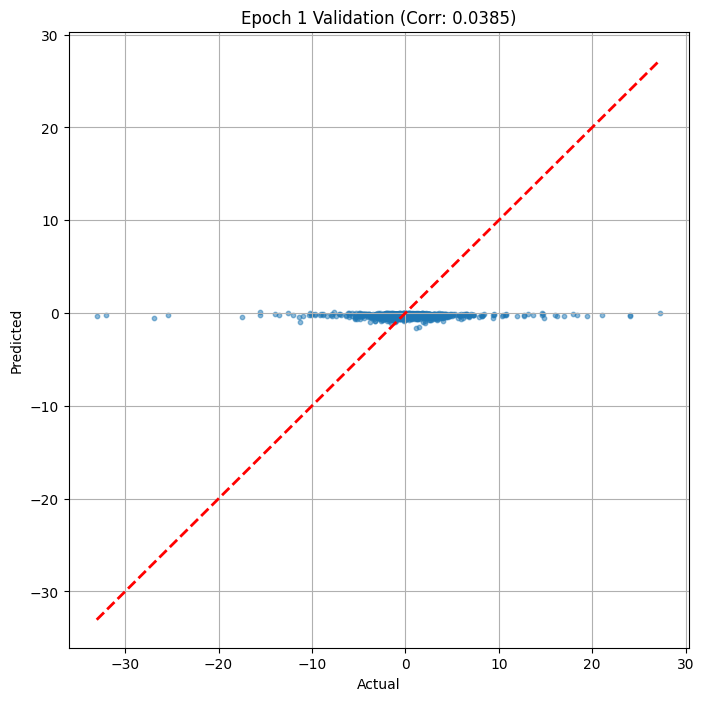

    Epoch   2 dates: 2018-12-27 to 2019-05-09 (92 days)
      Parquets: [28, 20, 15, 35] (200 tickers)
      Step   1/150 - Loss: 9.1181, MSE: 2.182647, Corr: 0.0030, Dir: 0.5000, N: 64
      Step   2/150 - Loss: 17.7236, MSE: 8.099977, Corr: -0.4749, Dir: 0.4688, N: 64
      Step   3/150 - Loss: 11.0391, MSE: 3.609092, Corr: -0.2584, Dir: 0.4375, N: 64
      Step   4/150 - Loss: 20.8245, MSE: 9.258458, Corr: -0.4241, Dir: 0.4375, N: 64
      Step   5/150 - Loss: 11.9325, MSE: 5.657657, Corr: 0.0323, Dir: 0.4375, N: 64
      Step   6/150 - Loss: 11.3135, MSE: 6.588570, Corr: 0.0260, Dir: 0.4062, N: 64
      Step   7/150 - Loss: 12.9653, MSE: 5.112549, Corr: 0.0091, Dir: 0.4375, N: 64
      Step   8/150 - Loss: 20.5137, MSE: 6.116329, Corr: -0.3924, Dir: 0.5469, N: 64
      Step   9/150 - Loss: 10.3515, MSE: 5.016953, Corr: -0.0742, Dir: 0.6094, N: 64
      Step  10/150 - Loss: 16.2646, MSE: 6.896872, Corr: 0.1526, Dir: 0.5312, N: 64
      Step  11/150 - Loss: 12.5967, MSE: 6.047742, Co

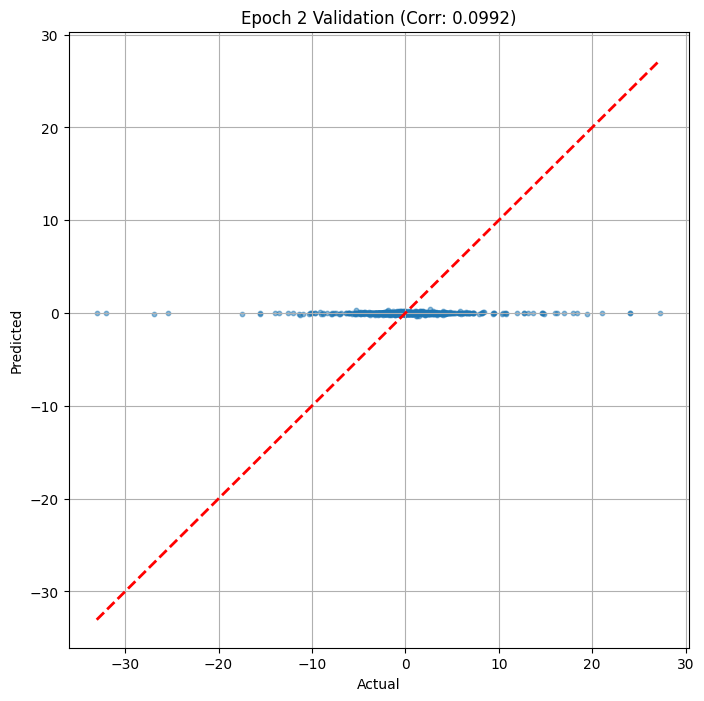

    Epoch   3 dates: 2019-04-26 to 2019-09-05 (92 days)
      Parquets: [35, 33, 11, 17] (200 tickers)
      Step   1/150 - Loss: 19.3147, MSE: 6.488238, Corr: 0.0420, Dir: 0.5938, N: 64
      Step   2/150 - Loss: 18.2004, MSE: 2.505820, Corr: 0.0369, Dir: 0.4531, N: 64
      Step   3/150 - Loss: 16.0223, MSE: 6.693379, Corr: 0.1022, Dir: 0.4688, N: 64
      Step   4/150 - Loss: 12.5509, MSE: 4.521862, Corr: -0.0030, Dir: 0.3750, N: 64
      Step   5/150 - Loss: 10.3386, MSE: 3.323083, Corr: -0.1135, Dir: 0.5625, N: 64
      Step   6/150 - Loss: 13.4992, MSE: 3.362480, Corr: -0.0340, Dir: 0.5156, N: 64
      Step   7/150 - Loss: 13.2551, MSE: 5.171911, Corr: 0.1045, Dir: 0.5000, N: 64
      Step   8/150 - Loss: 12.0820, MSE: 3.746795, Corr: -0.0131, Dir: 0.5156, N: 64
      Step   9/150 - Loss: 10.3326, MSE: 5.542786, Corr: 0.0067, Dir: 0.3594, N: 64
      Step  10/150 - Loss: 8.7176, MSE: 1.999618, Corr: 0.0086, Dir: 0.5625, N: 64
      Step  11/150 - Loss: 8.3338, MSE: 2.589031, Corr

KeyboardInterrupt: 

In [24]:
# ============= 2-Phase Training Loop =============
import time as time_module

print("\n" + "="*70)
print("Starting 2-Phase Rolling Window Training")
print("="*70)
print(f"\nTraining Configuration:")
print(f"  Batch size: {config['batch_size']} tickers per batch")
print(f"  Steps per epoch: {config['steps_per_epoch']}")
print(f"  Epochs per window: {config['epochs_per_window']}")
print(f"  Early stopping patience: {config['patience']}")
print(f"  Loss decay: {config['decay']}")
print(f"  Start date: {TRAINING_START_DATE.date()}")
print(f"  Total windows to train: {len(windows)}")
print(f"\n2-Phase Learning:")
print(f"  Phase A: Train {TRAIN_YEARS} years, validate {int(365.25 * VAL_YEARS)} days")
print(f"  Phase B: Fine-tune {PHASE_B_EPOCHS} epochs on validation data (LR={PHASE_B_LR})")
print(f"  Test: Next {int(365.25 * VAL_YEARS)} days (true out-of-sample)")
print("="*70 + "\n")

# Create trainer
trainer = RollingWindowTrainer(
    model=model,
    index=index,
    sampler=sampler,
    parquet_reader=parquet_reader,
    market_df=market_df,
    feature_cols=stock_feature_cols,
    target_col=TARGET_COL,
    config=config,
    device=DEVICE
)

# Track results separately for validation and test
all_window_results = []
all_val_preds = []
all_val_targets = []
all_test_preds = []
all_test_targets = []

# Optionally limit number of windows for testing (set to None for all)
MAX_WINDOWS = None  # Set to None to train all windows

windows_to_train = windows[:MAX_WINDOWS] if MAX_WINDOWS else windows
print(f"Training on {len(windows_to_train)} windows (MAX_WINDOWS={MAX_WINDOWS})\n")

total_start_time = time_module.time()

for window_idx, window in enumerate(windows_to_train, 1):
    window_start_time = time_module.time()
    
    print(f"\n{'#'*70}")
    print(f"# WINDOW {window_idx}/{len(windows_to_train)}")
    print(f"#   Train: {window['train_start'].date()} to {window['train_end'].date()}")
    print(f"#   Val:   {window['val_start'].date()} to {window['val_end'].date()}")
    print(f"#   Test:  {window['test_start'].date()} to {window['test_end'].date()}")
    print(f"{'#'*70}")
    
    # =========================================================================
    # PHASE A: Train on training data, validate on validation data
    # =========================================================================
    print("\n  === PHASE A: Training ===")
    phase_a_start = time_module.time()
    
    # Initialize optimizer for this window
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=config['learning_rate'], 
        weight_decay=0.1, 
        betas=(0.9, 0.95)
    )
    
    # Train on this window (LR resets at start of each epoch)
    results_A = trainer.train_window(window, optimizer)
    phase_a_time = time_module.time() - phase_a_start
    
    # Save Phase A checkpoint (best validation model)
    torch.save({
        'window': window_idx,
        'phase': 'A',
        'model_state_dict': results_A['best_model_state'],
        'val_loss': results_A['best_val_loss'],
    }, CHECKPOINT_DIR / f'window_{window_idx}_phase_A.pth')
    
    # Load best model from Phase A
    model.load_state_dict(results_A['best_model_state'])
    
    # Store Phase A validation results
    if len(results_A['best_preds']) > 0:
        all_val_preds.extend(results_A['best_preds'])
        all_val_targets.extend(results_A['best_targets'])
    
    print(f"\n  Phase A Summary ({phase_a_time/60:.1f} min):")
    print(f"    Best Val Loss: {results_A['best_val_loss']:.6f}")
    print(f"    Val MSE: {results_A['val_mse']:.6f}")
    print(f"    Val MAE: {results_A['val_mae']:.6f}")
    print(f"    Correlation: {results_A['val_corr']:.4f}")
    print(f"    Direction Accuracy: {results_A['val_direction_acc']:.4f}")
    print(f"    Epochs trained: {results_A['epochs_trained']}")
    
    # =========================================================================
    # PHASE B: Fine-tune on validation data (fresh optimizer, fixed epochs)
    # =========================================================================
    print("\n  === PHASE B: Fine-tuning on Validation Data ===")
    phase_b_start = time_module.time()
    
    results_B = trainer.finetune_on_validation(
        window,
        epochs=PHASE_B_EPOCHS,
        lr=PHASE_B_LR,
        steps_per_epoch=PHASE_B_STEPS_PER_EPOCH
    )
    phase_b_time = time_module.time() - phase_b_start
    
    # Save Phase B checkpoint (this is loaded for next window)
    torch.save({
        'window': window_idx,
        'phase': 'B',
        'model_state_dict': model.state_dict(),
        'phase_b_losses': results_B['train_losses'],
    }, CHECKPOINT_DIR / f'window_{window_idx}_phase_B.pth')
    
    print(f"  Phase B completed in {phase_b_time:.1f}s")
    
    # =========================================================================
    # TEST: Evaluate on true test set (after Phase B fine-tuning)
    # =========================================================================
    print("\n  === TEST: Evaluating on True Out-of-Sample Data ===")
    test_start_time = time_module.time()
    
    test_loss, test_preds, test_targets = trainer.evaluate_test(
        test_start=window['test_start'],
        test_end=window['test_end'],
        n_steps=config['val_steps']
    )
    test_eval_time = time_module.time() - test_start_time
    
    # Store test results
    if len(test_preds) > 0:
        all_test_preds.extend(test_preds)
        all_test_targets.extend(test_targets)
    
    # Compute test metrics
    if len(test_preds) > 1:
        test_mse = np.mean((test_preds - test_targets) ** 2)
        test_mae = np.mean(np.abs(test_preds - test_targets))
        test_corr = np.corrcoef(test_preds, test_targets)[0, 1]
        test_dir_acc = np.mean(np.sign(test_preds) == np.sign(test_targets))
    else:
        test_mse, test_mae, test_corr, test_dir_acc = 0.0, 0.0, 0.0, 0.0
    
    print(f"  Test Results ({test_eval_time:.1f}s):")
    print(f"    Test Loss: {test_loss:.6f}")
    print(f"    Test MSE: {test_mse:.6f}")
    print(f"    Test MAE: {test_mae:.6f}")
    print(f"    Correlation: {test_corr:.4f}")
    print(f"    Direction Accuracy: {test_dir_acc:.4f}")
    print(f"    N samples: {len(test_preds)}")
    
    # Store all results for this window
    window_total_time = time_module.time() - window_start_time
    results = {
        'window': window_idx,
        'train_start': window['train_start'],
        'train_end': window['train_end'],
        'val_start': window['val_start'],
        'val_end': window['val_end'],
        'test_start': window['test_start'],
        'test_end': window['test_end'],
        # Phase A results
        'phase_a_val_loss': results_A['best_val_loss'],
        'phase_a_val_mse': results_A['val_mse'],
        'phase_a_val_mae': results_A['val_mae'],
        'phase_a_val_corr': results_A['val_corr'],
        'phase_a_val_dir_acc': results_A['val_direction_acc'],
        'phase_a_epochs': results_A['epochs_trained'],
        'phase_a_time': phase_a_time,
        # Phase B results
        'phase_b_losses': results_B['train_losses'],
        'phase_b_time': phase_b_time,
        # Test results
        'test_loss': test_loss,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_corr': test_corr,
        'test_dir_acc': test_dir_acc,
        # Timing
        'window_time': window_total_time,
    }
    all_window_results.append(results)
    
    print(f"\n  Window {window_idx} completed in {window_total_time/60:.1f} minutes")
    
    # Note: Model continues with Phase B state for next window
    # (already saved as window_{idx}_phase_B.pth)

# =========================================================================
# Save CSV files matching liquid_model format
# =========================================================================
total_time = time_module.time() - total_start_time
print(f"\n{'='*70}")
print(f"Saving prediction CSVs...")
print("="*70)

# Save validation predictions CSV (Phase A results - before fine-tuning)
val_df = pd.DataFrame({
    'predictions': all_val_preds,
    'targets': all_val_targets
})
val_df.to_csv('validation_predictions_conditional.csv', index=False)
print(f"  Saved validation_predictions_conditional.csv ({len(val_df)} samples)")

# Save test predictions CSV (after Phase B fine-tuning - true out-of-sample)
test_df = pd.DataFrame({
    'predictions': all_test_preds,
    'targets': all_test_targets
})
test_df.to_csv('test_predictions_conditional.csv', index=False)
print(f"  Saved test_predictions_conditional.csv ({len(test_df)} samples)")

# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'windows_trained': len(windows_to_train),
    'config': config
}, 'final_factor_model_v2.pth')
print(f"  Saved final_factor_model_v2.pth")

print(f"\n{'='*70}")
print(f"2-Phase Rolling Window Training Complete!")
print(f"Total training time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"{'='*70}\n")

# Summary table
print("Summary across all windows:")
print(f"{'Window':<8} {'Val Loss':<12} {'Val Corr':<12} {'Test Loss':<12} {'Test Corr':<12} {'Test Dir':<10} {'Time':<8}")
print("-" * 86)
for result in all_window_results:
    print(f"{result['window']:<8} "
          f"{result['phase_a_val_loss']:<12.6f} "
          f"{result['phase_a_val_corr']:<12.4f} "
          f"{result['test_loss']:<12.6f} "
          f"{result['test_corr']:<12.4f} "
          f"{result['test_dir_acc']:<10.4f} "
          f"{result['window_time']/60:<8.1f}m")

if all_window_results:
    avg_val_corr = np.mean([r['phase_a_val_corr'] for r in all_window_results])
    avg_test_corr = np.mean([r['test_corr'] for r in all_window_results])
    avg_test_dir = np.mean([r['test_dir_acc'] for r in all_window_results])
    avg_window_time = np.mean([r['window_time'] for r in all_window_results])
    print("-" * 86)
    print(f"Average validation correlation: {avg_val_corr:.4f}")
    print(f"Average test correlation: {avg_test_corr:.4f}")
    print(f"Average test direction accuracy: {avg_test_dir:.4f}")
    print(f"Average window time: {avg_window_time/60:.1f} minutes")

# Parquet reader stats
reader_stats = parquet_reader.get_stats()
print(f"\nParquet Reader Statistics:")
print(f"  Read count: {reader_stats['read_count']}")
print(f"  Total rows read: {reader_stats['rows_read']}")
print(f"  Avg rows per read: {reader_stats['avg_rows_per_read']:.0f}")

## 8. Summary

This notebook implements the **LiquidPremia** Conditional Factor Model:

$$\hat{r}_{i,t+H} = b_{i,t}^{\top} \lambda_t$$

### Training Strategy:
1. **Data Loading**: Each epoch randomly selects 3 stock batch files from 62 available
2. **Date Alignment**: Stock features are aligned with market state vector by date
3. **Walk-Forward**: Sliding windows with continuous model learning
4. **Loss**: Exponentially weighted MSE with directional penalty

### Model Components:
1. **Factor Premia Model** (`MultiScaleLiquid`): λ_t = g(m_t)
2. **Stock Exposure Model** (`StockExposureModel`): b_{i,t} = f(x_{i,t})
3. **Prediction**: Element-wise product summed to scalar